### One-Dimensional (1D) Lattice Described by the Bose-Hubbard Hamiltonian

$$
\hat{H}
=
-J\sum_{j=0}^{L-2}
\left(
\hat{b}_{j+1}^{\dagger}\hat{b}_{j}
+
\hat{b}_{j}^{\dagger}\hat{b}_{j+1}
\right)
+
\frac{U}{2}
\sum_{j=0}^{L-1}
\hat{n}_{j}\left(\hat{n}_{j}-1\right)
$$

The operators act on the occupation-number state $\lvert n_j\rangle$ as

$$
\hat{b}_{j}\lvert n_j\rangle
=
\sqrt{n_j}\,\lvert n_j-1\rangle,
$$

$$
\hat{b}_{j}^{\dagger}\lvert n_j\rangle
=
\sqrt{n_j+1}\,\lvert n_j+1\rangle,
$$

and

$$
\hat{n}_{j}\lvert n_j\rangle
=
n_j\lvert n_j\rangle,
\qquad
\hat{n}_{j}
=
\hat{b}_{j}^{\dagger}\hat{b}_{j}.
$$





In [1]:
from IPython.display import HTML, display
import numpy as np
from hamiltonian_1d import ReducedBoseHubbard
from dynamics_1d import BoseHubbardDynamics

#### Build the reduced Hamiltonian

In [9]:
BH_model = ReducedBoseHubbard(
    L=10,
    N=15,
    J=1.0,
    U=0.0
)

# Display information about the reduced system.
print("Number of basis states:", len(BH_model.basis_states))
print("Hamiltonian shape:", BH_model.H.shape)
print("Hamiltonian type:", type(BH_model.H))
print("Hamiltonian is Hermitian:", BH_model.H.isherm)

Number of basis states: 1307504
Hamiltonian shape: (1307504, 1307504)
Hamiltonian type: <class 'qutip.core.qobj.Qobj'>
Hamiltonian is Hermitian: True


#### Run the dynamics

In [10]:

dynamics = BoseHubbardDynamics(
    BH_model,
    t_start=0,
    t_end=10,
    num_times=300
)


psi0, result, site_number_expect, N_expect = (
    dynamics.run_dynamics(
        random_fock_state=False,
        random_superposition_of_fock_states=False,
        state_loaded_from_numpy_file=None,
        localized_state_site=2
    )
)


In [11]:

# Expected boson number at a chosen site and time


site = 2
chosen_time = 5.0

if not isinstance(site, (int, np.integer)):
    raise TypeError("The site number must be an integer.")

if not 0 <= site < BH_model.L:
    raise ValueError("The selected site is outside the lattice.")

if not dynamics.t_start <= chosen_time <= dynamics.t_end:
    raise ValueError("The selected time is outside the simulated interval.")


# Find the simulated time closest to chosen_time
time_index = np.argmin(
    np.abs(dynamics.tlist - chosen_time)
)

actual_time = dynamics.tlist[time_index]

site_expectation = site_number_expect[
    site,
    time_index
]


print("Site:", site)
print("Requested time:", chosen_time)
print("Closest simulated time:", actual_time)
print("Expected boson number:", site_expectation)









Site: 2
Requested time: 5.0
Closest simulated time: 4.983277591973244
Expected boson number: 0.958734276692


#### Plots

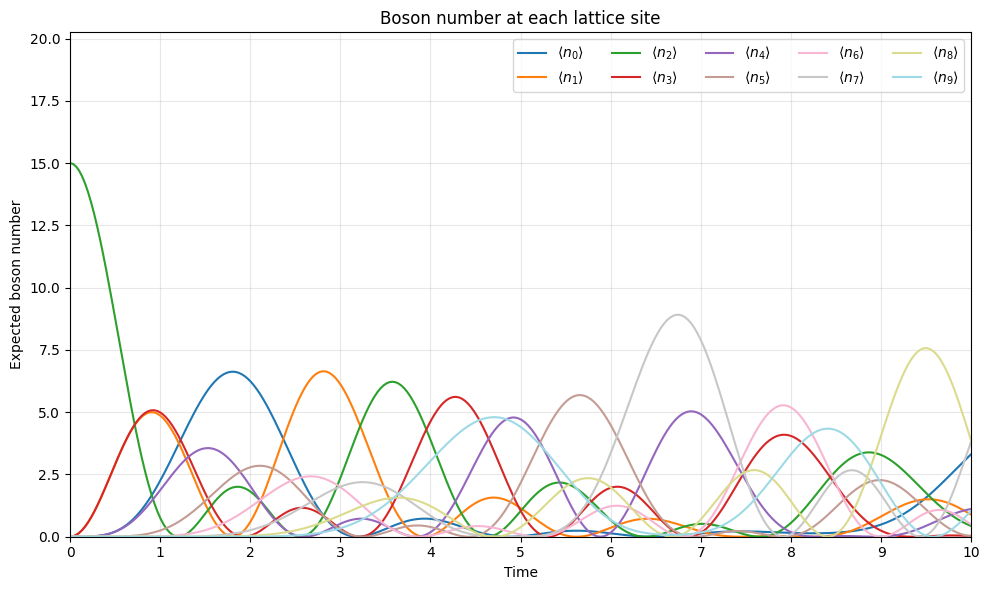

In [12]:
dynamics.plot_site_numbers(site_number_expect)

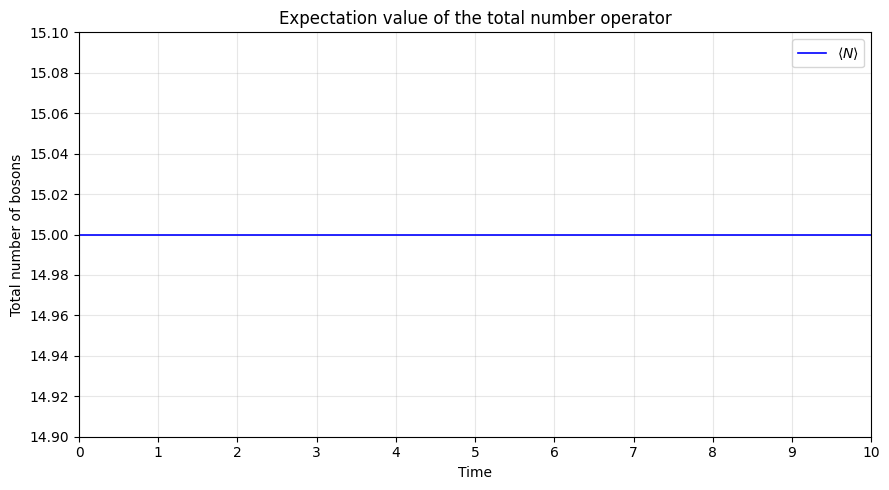

In [13]:
dynamics.plot_total_number(N_expect)


In [14]:

animation = dynamics.animate_site_numbers(
    site_number_expect
)

animation_html = HTML(
    animation.to_jshtml()
)

display(animation_html)